In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

Problem 1

In [24]:
problem_1 = pd.DataFrame({'problem_1':[1,1.75,2,3,3.25,4]})

<Axes: xlabel='hw_data', ylabel='Proportion'>

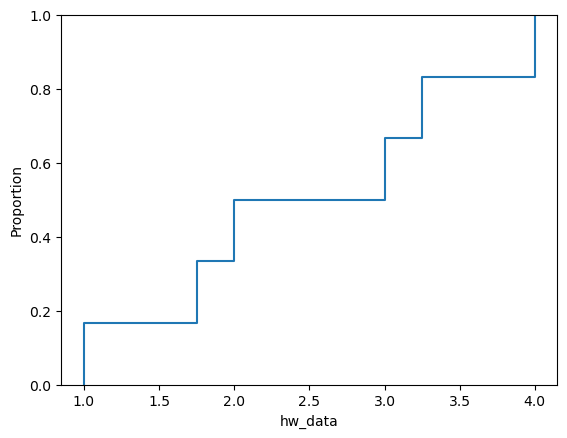

In [ ]:
#a
sns.ecdfplot( data=problem_1, x='problem_1')

In [28]:
h_sm = sm.nonparametric.bandwidths.bw_silverman(problem_1)
h_uniform = 1.74 * h_sm
print(h_uniform)
meow= np.std(problem_1)  
h = 1.84 * meow * 6**(-0.2)
h

problem_1    1.115456
dtype: float64


1.2991670409500977

problem 2

In [30]:
problem_1 = pd.DataFrame({'problem_1':[-1,-0.5,0,0.5,1]})

In [16]:
kde = sm.nonparametric.KDEUnivariate(problem_1)
kde.fit(kernel="uni", fft=False, bw=0.6)
kde.evaluate(0) 

array([0.5])

In [21]:

data = np.asarray(problem_1).ravel()
F = stats.ecdf(data).cdf.evaluate   # scipy >= 1.11
x, h = 0, 0.1

result = (F(x + h) - F(x - h)) / (2 * h)
print(result)

0.9999999999999998


In [31]:
meow= np.std(problem_1)  
mu, sigma = 0, meow
f0 = np.exp(-(0 - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
f0

np.float64(0.5641895835477563)

Problem 3

In [33]:
problem_3=pd.DataFrame({'problem_3':[5,7,7,8,10]})

In [41]:
data = np.asarray(problem_3, dtype=float).ravel()
n, h = len(data), 1.5
data2 = [6, 6.5, 7, 8, 8.5]

for x in data2:
    count = np.sum(np.abs(data - x) < h)
    f_hat = count / (2 * n * h)
    print(x, count, f_hat)


6 3 0.2
6.5 2 0.13333333333333333
7 3 0.2
8 3 0.2
8.5 1 0.06666666666666667


In [38]:
data = np.asarray(problem_3, dtype=float).ravel()
kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="gau", fft=False, bw=1.5)
data2 = [6,6.5,7,8,8.5]
for i in data2:
    print(kde.evaluate(i))

[0.15116668]
[0.16865731]
[0.17804448]
[0.16744524]
[0.15060231]


In [40]:
data = np.asarray(problem_3, dtype=float).ravel()
n, h = len(data), 1.5
data2 = [6, 6.5, 7, 8, 8.5]

kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="gau", fft=False, bw=h)

for x in data2:
    u = (data - x) / h
    table = pd.DataFrame({
        "x_i": data,
        "u = (x_i - x)/h": u,
        "u^2 / 2": u**2 / 2,
        "exp(-u^2/2)": np.exp(-u**2 / 2),
    })
    total = table["exp(-u^2/2)"].sum()
    f_hat = total / np.sqrt(2 * np.pi) / (n * h)

    print(f"\n===== x = {x} =====")
    print(table.round(5))
    print("sum of exps:      ", round(total, 5))
    print("f_hat (by hand):  ", round(f_hat, 5))
    print("f_hat (statsmodels):", round(kde.evaluate(x)[0], 5))


===== x = 6 =====
    x_i  u = (x_i - x)/h  u^2 / 2  exp(-u^2/2)
0   5.0         -0.66667  0.22222      0.80074
1   7.0          0.66667  0.22222      0.80074
2   7.0          0.66667  0.22222      0.80074
3   8.0          1.33333  0.88889      0.41111
4  10.0          2.66667  3.55556      0.02857
sum of exps:       2.84189
f_hat (by hand):   0.15117
f_hat (statsmodels): 0.15117

===== x = 6.5 =====
    x_i  u = (x_i - x)/h  u^2 / 2  exp(-u^2/2)
0   5.0         -1.00000  0.50000      0.60653
1   7.0          0.33333  0.05556      0.94596
2   7.0          0.33333  0.05556      0.94596
3   8.0          1.00000  0.50000      0.60653
4  10.0          2.33333  2.72222      0.06573
sum of exps:       3.17071
f_hat (by hand):   0.16866
f_hat (statsmodels): 0.16866

===== x = 7 =====
    x_i  u = (x_i - x)/h  u^2 / 2  exp(-u^2/2)
0   5.0         -1.33333  0.88889      0.41111
1   7.0          0.00000  0.00000      1.00000
2   7.0          0.00000  0.00000      1.00000
3   8.0          0.6666

<Axes: ylabel='Density'>

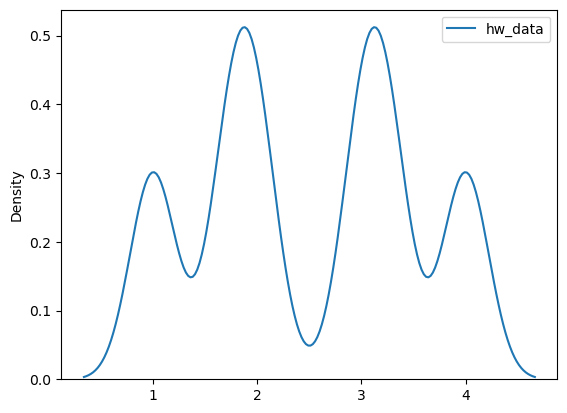

In [9]:
#b
h=0.2 
sns.kdeplot(data_1,bw_method=h)

In [ ]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde

<Axes: ylabel='Density'>

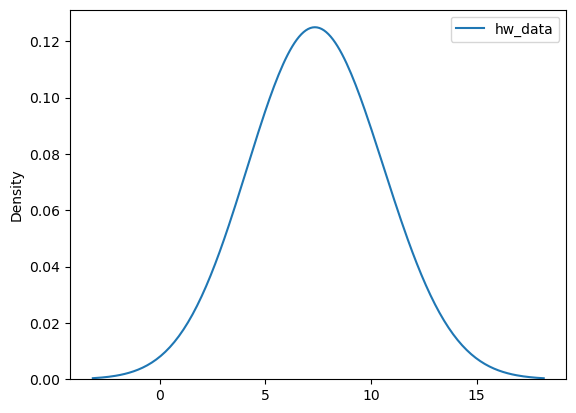

In [10]:

h=1.5
data_1 = pd.DataFrame({'hw_data':[5,7,7,8,10]})
sns.kdeplot(data_1,bw_method=h)

In [4]:
df_ps = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df_ps

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


<Axes: xlabel='ejection_fraction', ylabel='Density'>

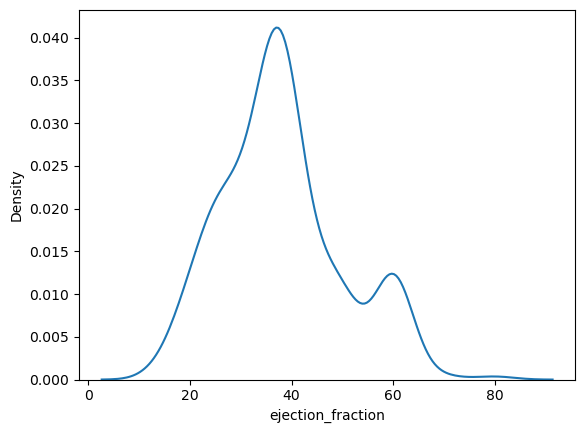

In [ ]:
#Problem 4 part a
sns.kdeplot(df_ps['ejection_fraction'])

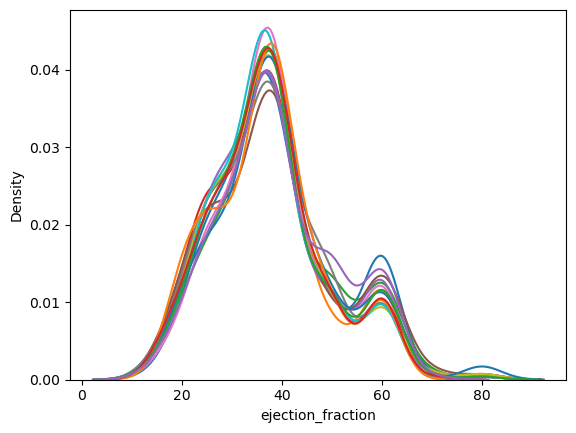

In [ ]:
#Problem 4 part b, should I do separate graphs for each one? 
for i in range(15):
    sns.kdeplot(df_ps['ejection_fraction'].sample(frac=1.0,replace=True))

Original reliable for ejection_fraction 0-20, and around 40 and 70. There is a lot of variation for 37-38 and 50-60.